In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Diwali Sales Data.csv', encoding= 'unicode_escape')

In [6]:
print(df)

       User_ID    Cust_name Product_ID Gender Age Group  Age  Marital_Status  \
0      1002903    Sanskriti  P00125942      F     26-35   28               0   
1      1000732       Kartik  P00110942      F     26-35   35               1   
2      1001990        Bindu  P00118542      F     26-35   35               1   
3      1001425       Sudevi  P00237842      M      0-17   16               0   
4      1000588         Joni  P00057942      M     26-35   28               1   
...        ...          ...        ...    ...       ...  ...             ...   
11246  1000695      Manning  P00296942      M     18-25   19               1   
11247  1004089  Reichenbach  P00171342      M     26-35   33               0   
11248  1001209        Oshin  P00201342      F     36-45   40               0   
11249  1004023       Noonan  P00059442      M     36-45   37               0   
11250  1002744      Brumley  P00281742      F     18-25   19               0   

                State      Zone       O

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [8]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)
df.dropna(inplace=True)
df['Amount'] = df['Amount'].astype(int)
print(df['Amount'].dtypes)
print(df.columns)
df.rename(columns={'Marital_Status': 'Shaadi'}, inplace=True)
print(df.describe())
print(df[['Age', 'Orders', 'Amount']].describe())

int64
Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')
            User_ID           Age        Shaadi        Orders        Amount
count  1.123900e+04  11239.000000  11239.000000  11239.000000  11239.000000
mean   1.003004e+06     35.410357      0.420055      2.489634   9453.610553
std    1.716039e+03     12.753866      0.493589      1.114967   5222.355168
min    1.000001e+06     12.000000      0.000000      1.000000    188.000000
25%    1.001492e+06     27.000000      0.000000      2.000000   5443.000000
50%    1.003064e+06     33.000000      0.000000      2.000000   8109.000000
75%    1.004426e+06     43.000000      1.000000      3.000000  12675.000000
max    1.006040e+06     92.000000      1.000000      4.000000  23952.000000
                Age        Orders        Amount
count  11239.000000  11239.000000  11239.000000
mean      35.

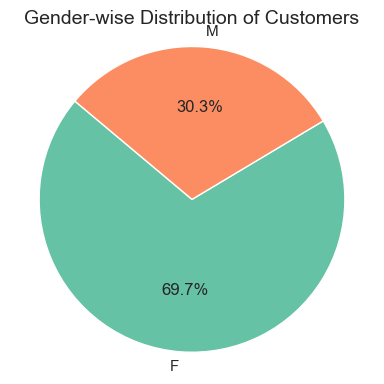

In [27]:
gender_counts = df['Gender'].value_counts()
labels = gender_counts.index
sizes = gender_counts.values

plt.figure(figsize=(4, 4))  
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set2.colors)
plt.title("Gender-wise Distribution of Customers", fontsize=14)
plt.axis('equal')  
plt.tight_layout()
plt.show()


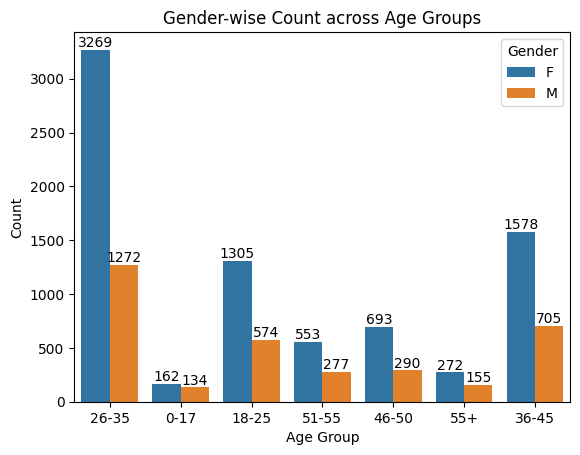

In [10]:
# Gender-wise count across age groups
ax = sns.countplot(data=df, x='Age Group', hue='Gender')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Gender-wise Count across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

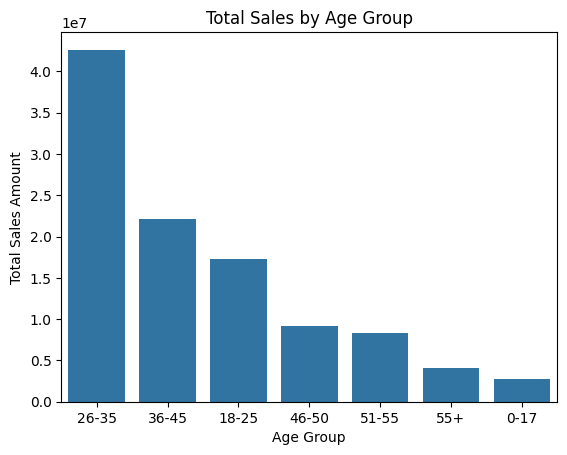

In [11]:
# Total sales by age group
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Age Group', y='Amount', data=sales_age)
plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales Amount")
plt.show()

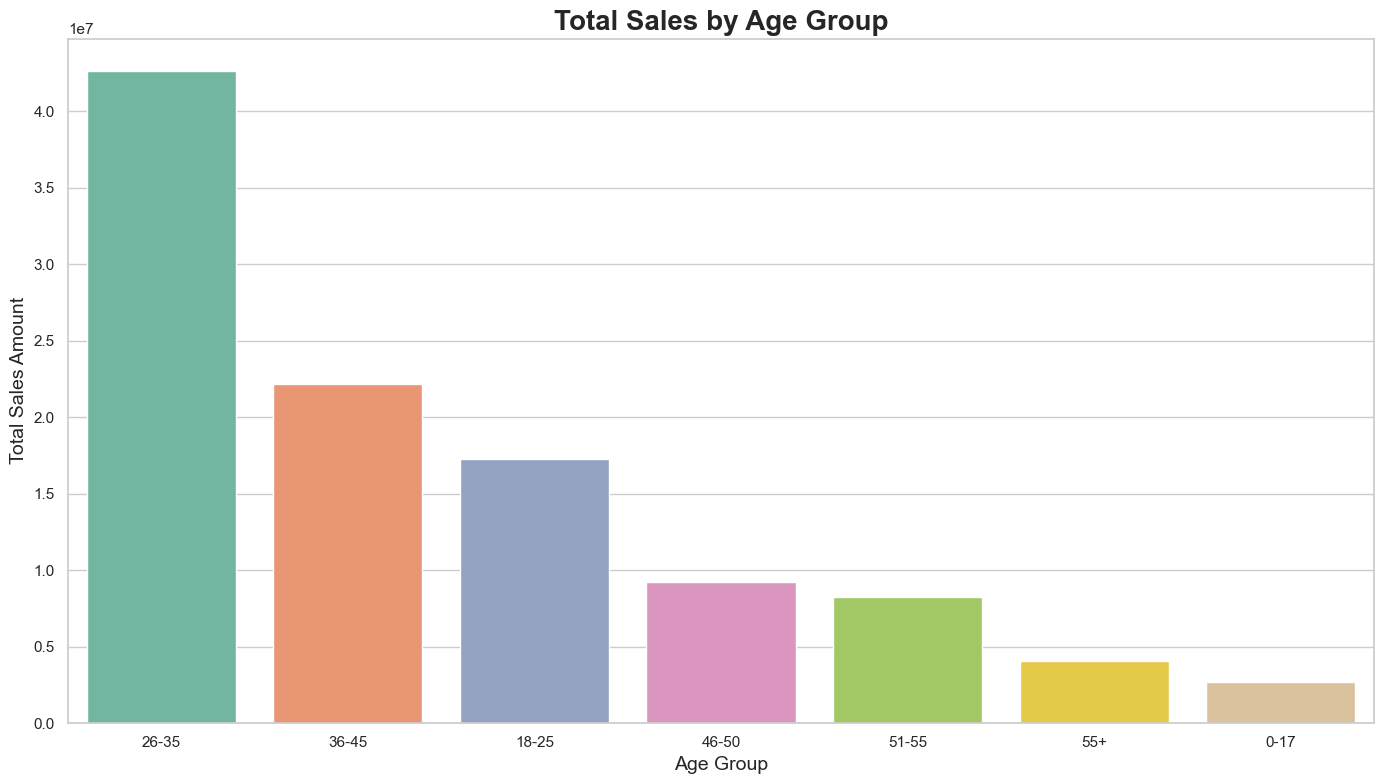

In [28]:
# Total number of orders from top 10 states
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

# Set larger figure size and style
plt.figure(figsize=(14, 8))  # You can adjust (width, height) as needed
sns.set_style("whitegrid")

# Plot
sns.barplot(x='Age Group', y='Amount', data=sales_age, hue='Age Group', palette='Set2', dodge=False, legend=False)

# Titles and labels
plt.title("Total Sales by Age Group", fontsize=20, fontweight='bold')
plt.xlabel("Age Group", fontsize=14)
plt.ylabel("Total Sales Amount", fontsize=14)

# Apply tight layout
plt.tight_layout()

# Show plot
plt.show()

In [13]:
sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

In [14]:
# Data setup for polar chart
labels = sales_state['State']
orders = sales_state['Orders']
angles = np.linspace(0, 2 * np.pi, len(orders), endpoint=False)

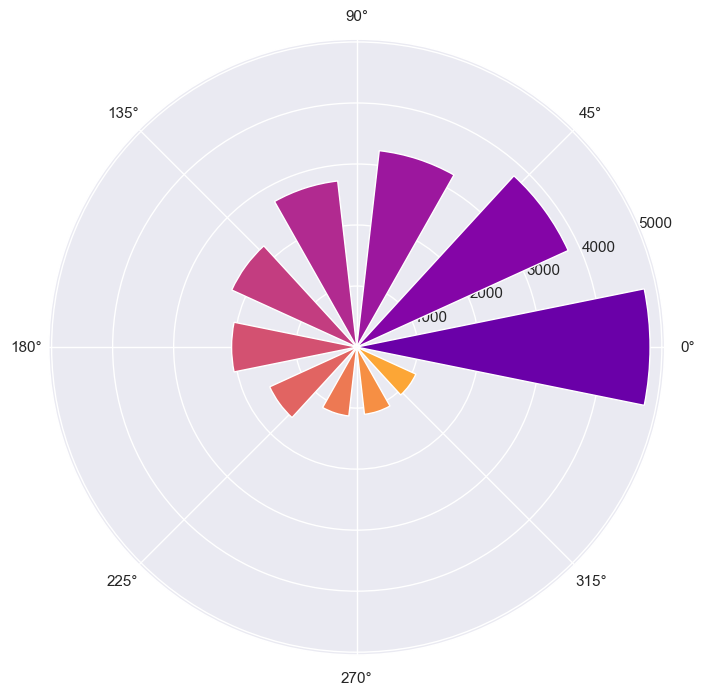

In [15]:
# Polar bar plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
bars = ax.bar(angles, orders, width=0.4, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(orders))))

In [16]:
# X-ticks as labels
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels([])  # Remove circular grid labels
ax.set_title("Top 10 States by Number of Orders (Iris Chart)", y=1.1)

Text(0.5, 1.1, 'Top 10 States by Number of Orders (Iris Chart)')

In [17]:
# Rotate labels to be readable
for label, angle in zip(ax.get_xticklabels(), angles):
    label.set_rotation(np.degrees(angle))
    label.set_horizontalalignment('center')

plt.tight_layout()
plt.show()

<Figure size 1500x500 with 0 Axes>

In [18]:
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

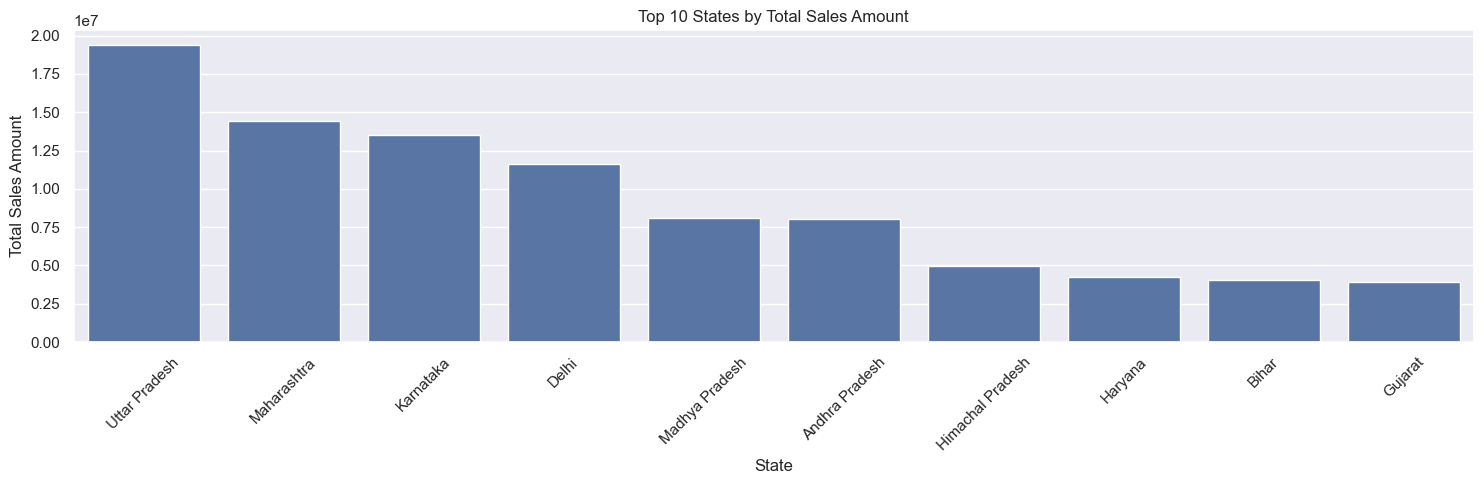

In [19]:
sns.set(rc={'figure.figsize': (15, 5)})
sns.barplot(data=sales_state, x='State', y='Amount')
plt.title("Top 10 States by Total Sales Amount")
plt.xlabel("State")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

In [21]:
# Set figure size
sns.set(rc={'figure.figsize': (15, 5)})
plt.figure(figsize=(15, 5))
sns.set_style("whitegrid")

<Figure size 1500x500 with 0 Axes>

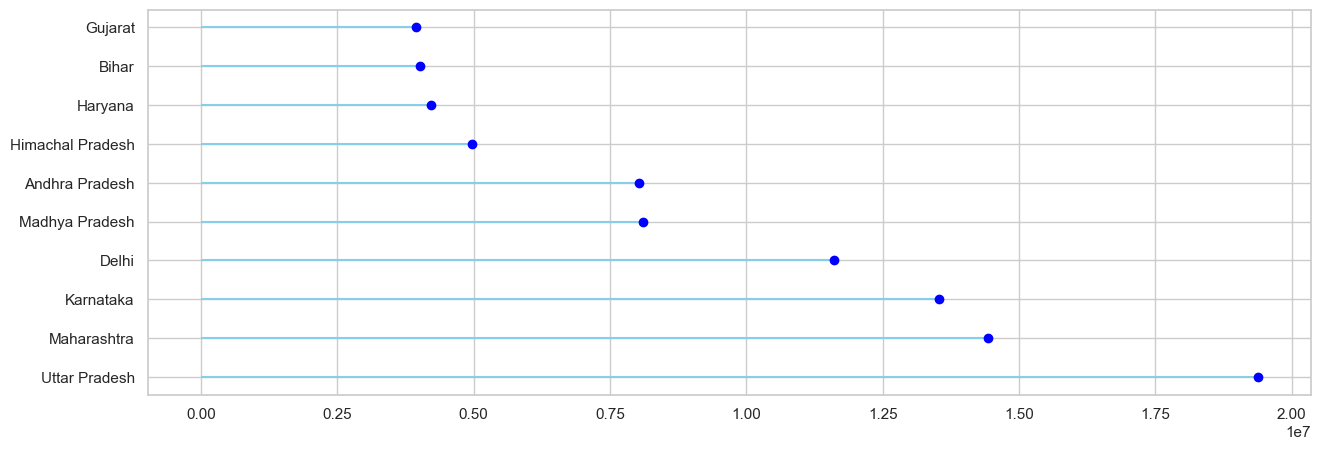

In [22]:
# Draw dot chart (lollipop chart)
plt.hlines(y=sales_state['State'], xmin=0, xmax=sales_state['Amount'], color='skyblue')
plt.plot(sales_state['Amount'], sales_state['State'], "o", color='blue')

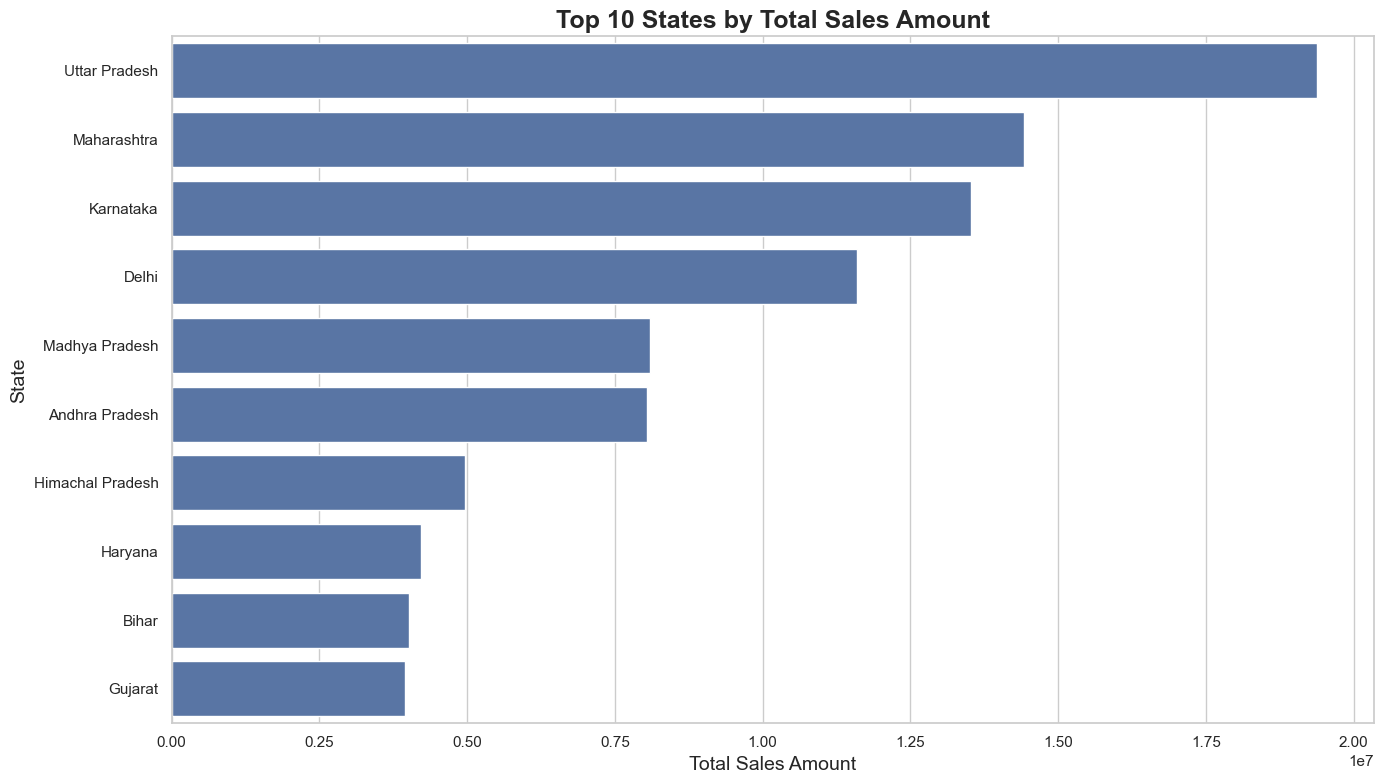

In [31]:
sales_state = df.groupby('State', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

sns.barplot(x='Amount', y='State', data=sales_state)

plt.title("Top 10 States by Total Sales Amount", fontsize=18, fontweight='bold')
plt.xlabel("Total Sales Amount", fontsize=14)
plt.ylabel("State", fontsize=14)

plt.tight_layout()
plt.show()


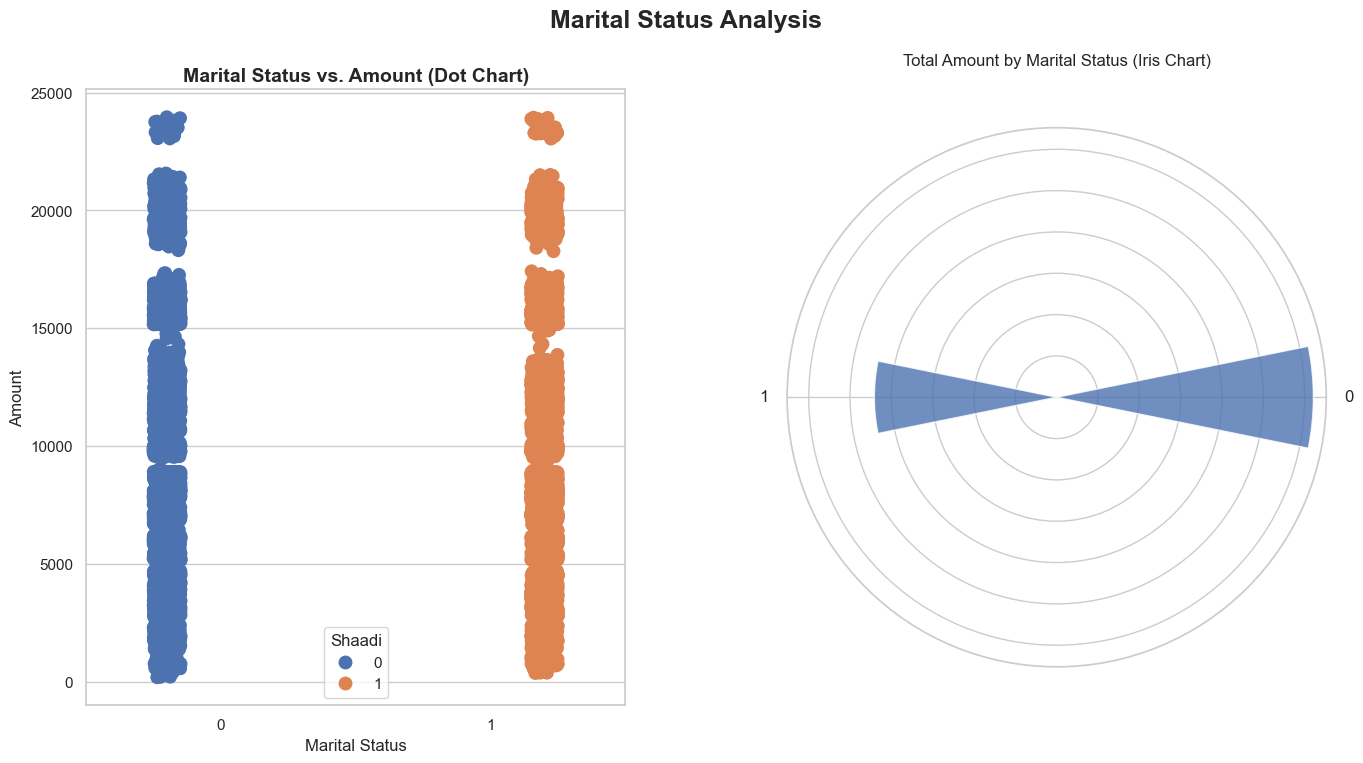

In [32]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 8))
grid = plt.GridSpec(1, 2, wspace=0.3)

# Dot Chart (Strip Plot)
ax1 = plt.subplot(grid[0, 0])
sns.stripplot(data=df, x='Shaadi', y='Amount', hue='Shaadi', dodge=True, size=10, ax=ax1)
ax1.set_title("Marital Status vs. Amount (Dot Chart)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Marital Status")
ax1.set_ylabel("Amount")
ax1.legend(title="Shaadi")

# Iris-style Radial Bar Chart
ax2 = plt.subplot(grid[0, 1], polar=True)
marital_sales = df.groupby('Shaadi')['Amount'].sum()
angles = np.linspace(0, 2 * np.pi, len(marital_sales), endpoint=False)
values = marital_sales.values
labels = marital_sales.index

bars = ax2.bar(angles, values, width=0.4, bottom=0.0, alpha=0.8)
ax2.set_xticks(angles)
ax2.set_xticklabels(labels, fontsize=12)
ax2.set_title("Total Amount by Marital Status (Iris Chart)", y=1.1)
ax2.set_yticklabels([])

plt.suptitle("Marital Status Analysis", fontsize=18, fontweight='bold')
plt.show()


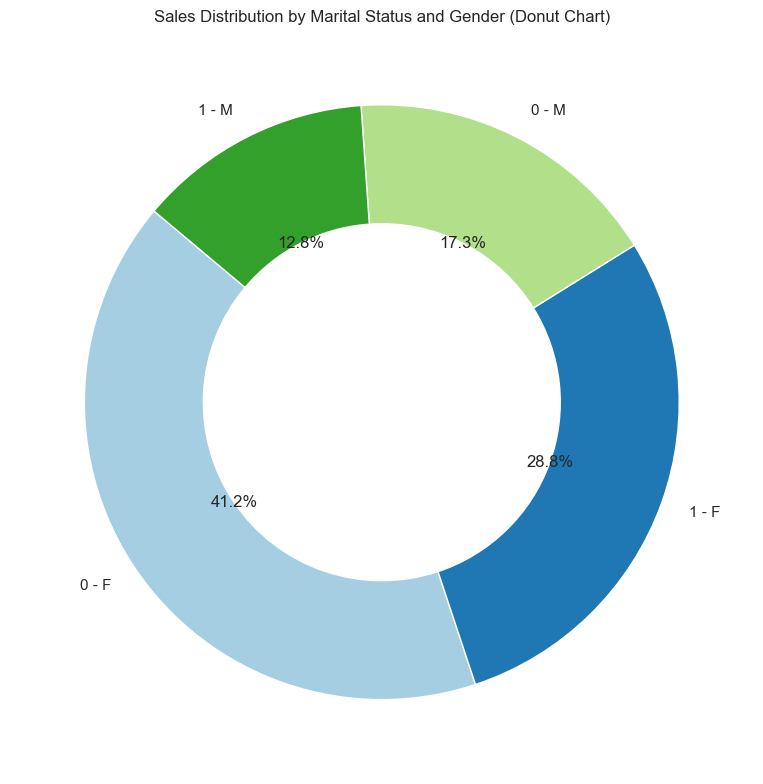

In [29]:
# Grouping again just to be safe (in case you didn't run earlier)
sales_state = df.groupby(['Shaadi', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

# Create labels and sizes
labels = sales_state.apply(lambda row: f"{row['Shaadi']} - {row['Gender']}", axis=1)
sizes = sales_state['Amount']

# Define colors (optional)
colors = plt.cm.Paired.colors

# Create donut chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, startangle=140, wedgeprops={'width': 0.4}, autopct='%1.1f%%')

plt.title("Sales Distribution by Marital Status and Gender (Donut Chart)")
plt.tight_layout()
plt.show()

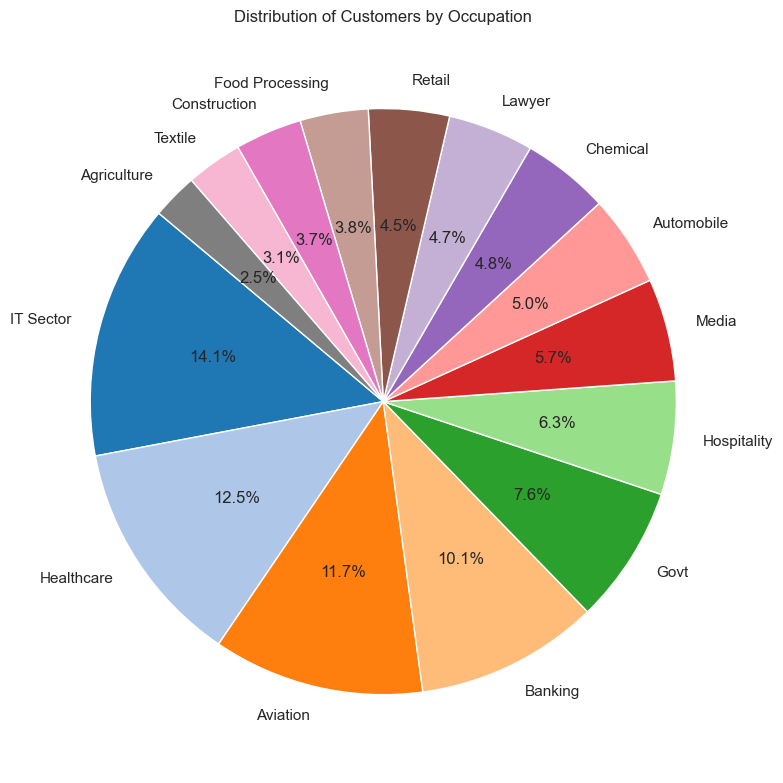

In [31]:
 # Count occurrences of each occupation
occupation_counts = df['Occupation'].value_counts()

labels = occupation_counts.index
sizes = occupation_counts.values

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title("Distribution of Customers by Occupation")
plt.axis('equal')  
plt.tight_layout()
plt.show()

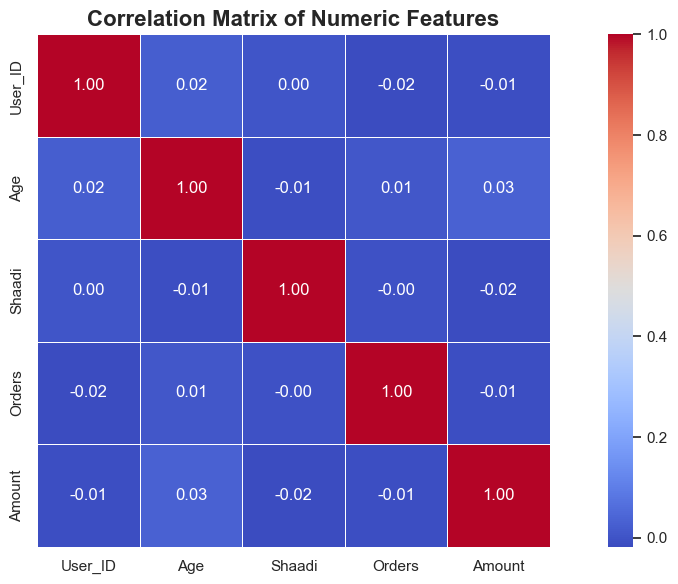

In [33]:
# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="white")

# Compute correlation matrix for all numeric columns
corr_matrix = df.corr(numeric_only=True)

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True)

# Add title
plt.title("Correlation Matrix of Numeric Features", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

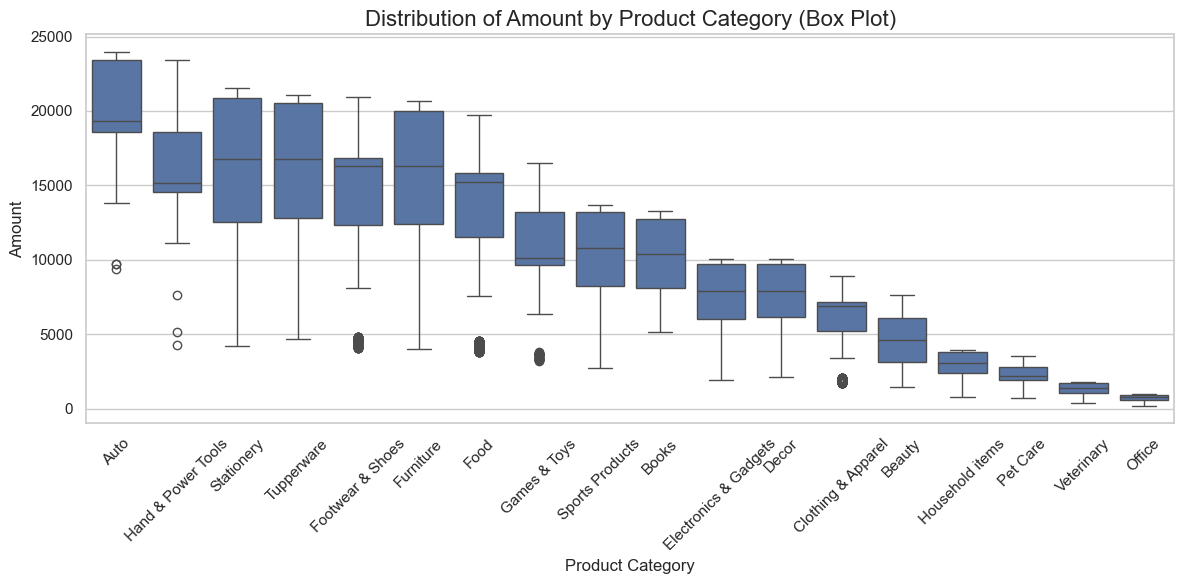

In [34]:
# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Box plot
sns.boxplot(data=df, x='Product_Category', y='Amount')

# Titles and labels
plt.title("Distribution of Amount by Product Category (Box Plot)", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

<Axes: xlabel='Product_Category', ylabel='Amount'>

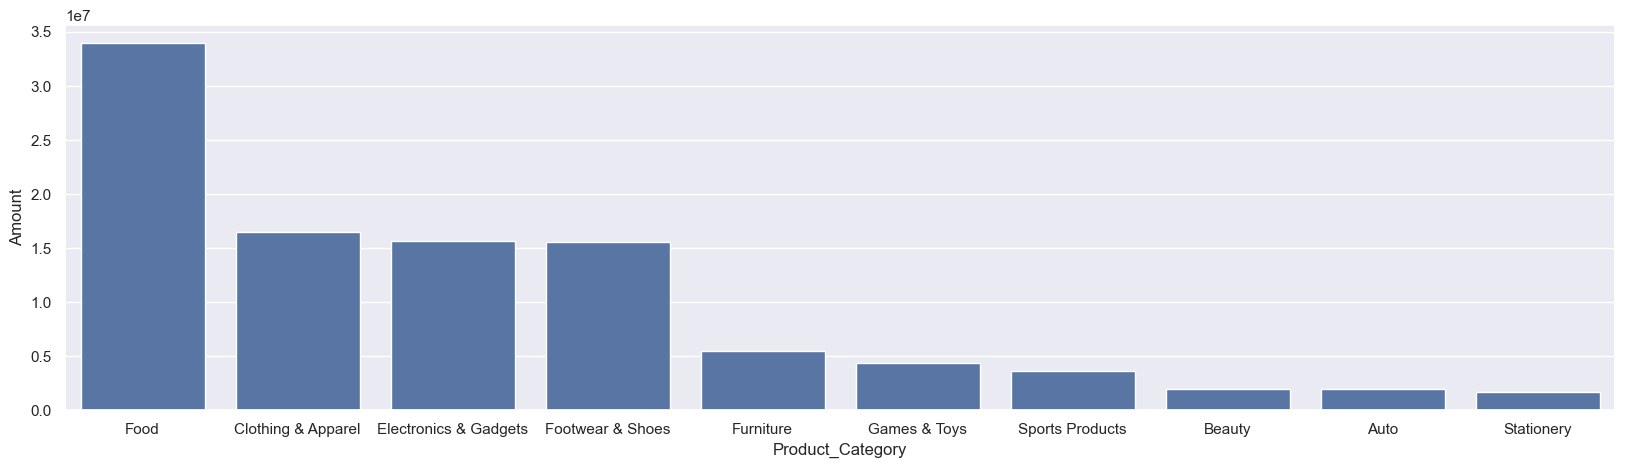

In [36]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount')

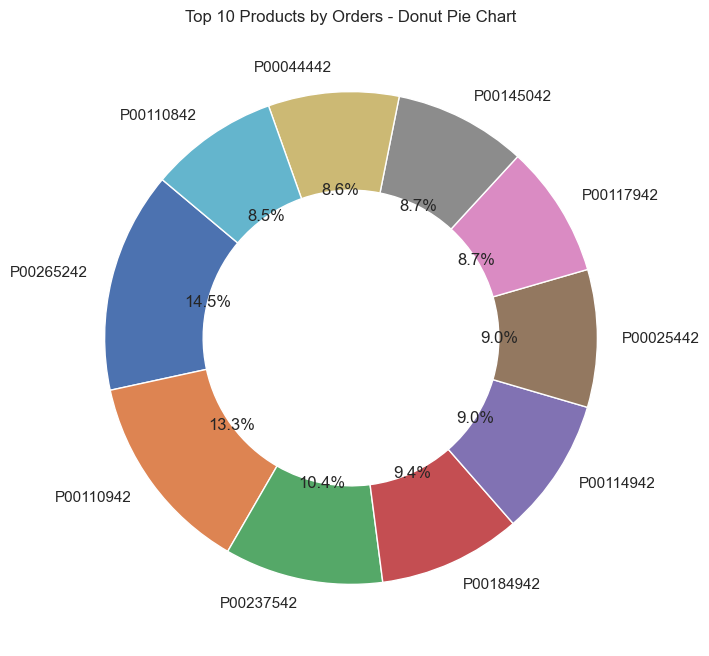

In [41]:
# Grouping and sorting the data
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

# Plotting a donut pie chart
plt.figure(figsize=(8, 8))
plt.pie(sales_state['Orders'], 
        labels=sales_state['Product_ID'], 
        autopct='%1.1f%%', 
        startangle=140, 
        wedgeprops=dict(width=0.4))  # this makes it a donut

# Title
plt.title('Top 10 Products by Orders - Donut Pie Chart')

# Show plot
plt.show()

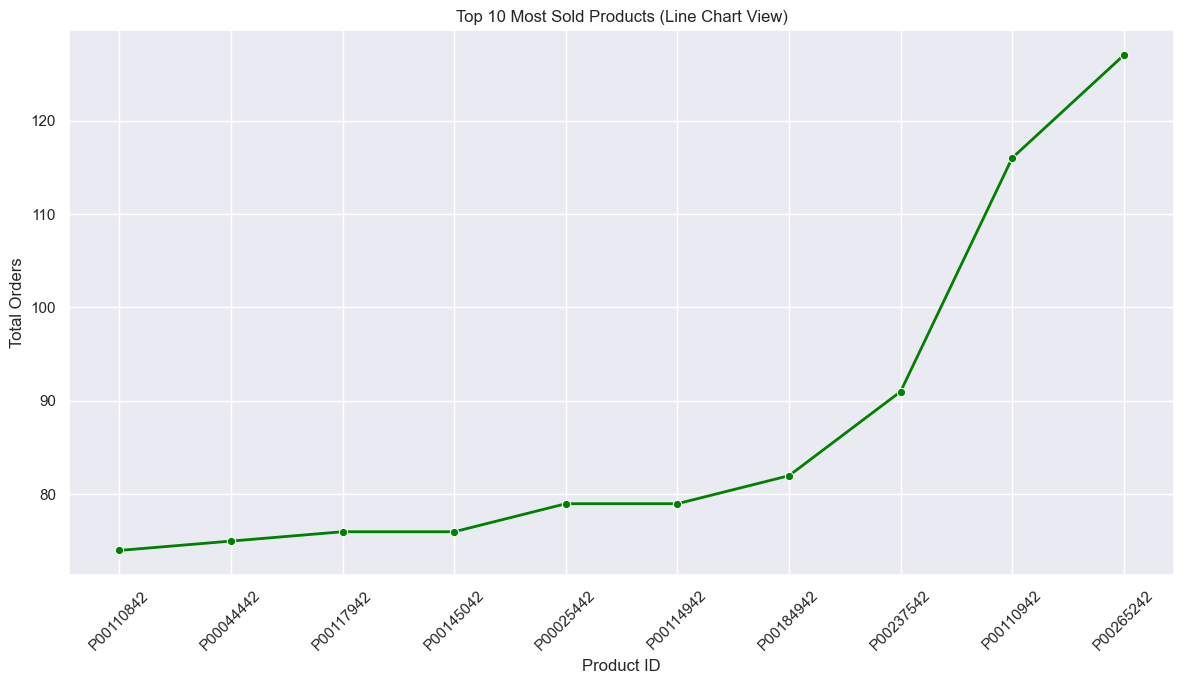

In [43]:
# Assuming 'df' is already defined and contains 'Product_ID' and 'Orders'
# Prepare data
top10_products = df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending=False).reset_index()

# Sort Product_IDs alphabetically or by value for smooth line
top10_products = top10_products.sort_values(by='Orders')

# Plot
plt.figure(figsize=(12,7))
sns.lineplot(data=top10_products, x='Product_ID', y='Orders', marker='o', linewidth=2, color='green')

# Add title and labels
plt.title('Top 10 Most Sold Products (Line Chart View)')
plt.xlabel('Product ID')
plt.ylabel('Total Orders')

# Optional: Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()

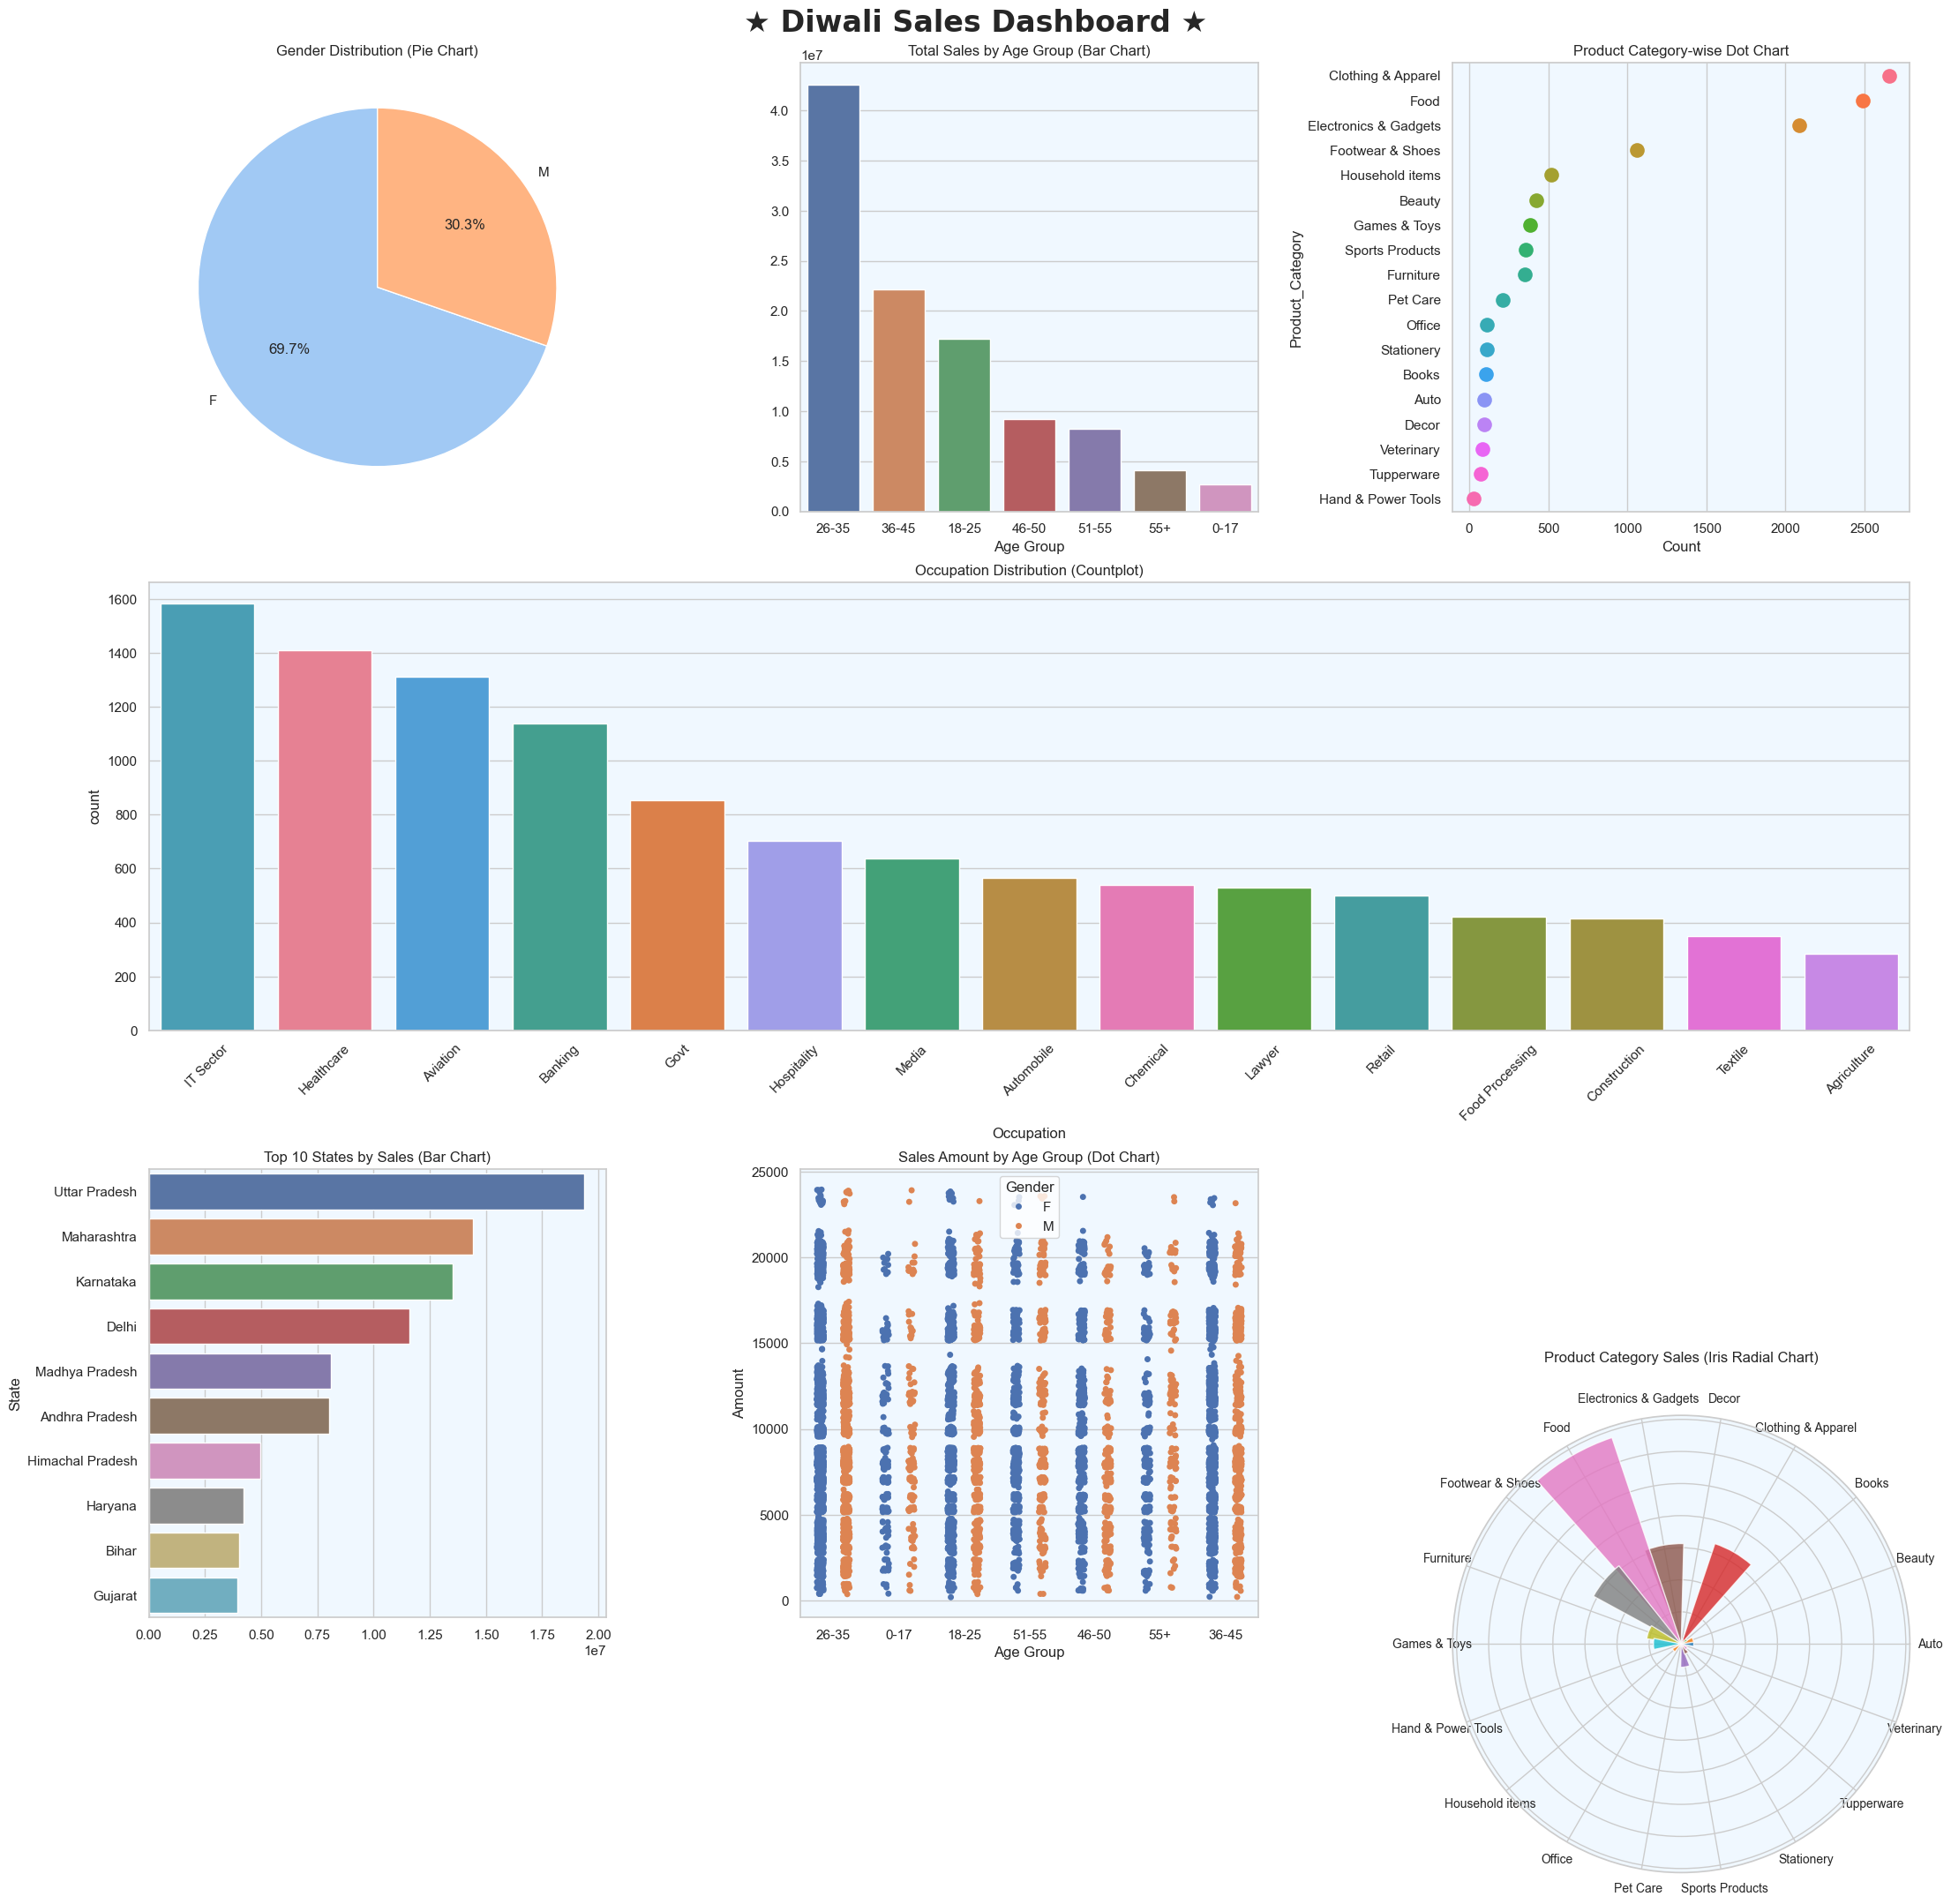

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style='whitegrid')

# Sample DataFrame (Replace this with your actual DataFrame `df`)
# df = pd.read_csv("your_diwali_data.csv")  # Make sure this is defined

# Create subplots with constrained layout
fig = plt.figure(constrained_layout=True, figsize=(22, 24))
gs = fig.add_gridspec(4, 3)
fig.suptitle("★ Diwali Sales Dashboard ★", fontsize=24, fontweight='bold', fontname='DejaVu Sans')

# Define background color for each subplot
bg_color = '#f0f8ff'

# Pie Chart - Gender distribution
gender_counts = df['Gender'].value_counts()
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(bg_color)
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax1.set_title("Gender Distribution (Pie Chart)")

# Bar Chart - Age Group vs Total Sales
sales_age = df.groupby('Age Group')['Amount'].sum().sort_values(ascending=False)
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(bg_color)
sns.barplot(x=sales_age.index, y=sales_age.values, hue=sales_age.index, dodge=False, legend=False, ax=ax2)
ax2.set_title("Total Sales by Age Group (Bar Chart)")

# Dot Chart - Product Category-wise count
product_counts = df['Product_Category'].value_counts().reset_index()
product_counts.columns = ['Product_Category', 'Count']
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(bg_color)
sns.stripplot(x='Count', y='Product_Category', data=product_counts, hue='Product_Category', dodge=False, legend=False, size=12, ax=ax3)
ax3.set_title("Product Category-wise Dot Chart")

# Countplot - Occupation-wise
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor(bg_color)
sns.countplot(data=df, x='Occupation', hue='Occupation', legend=False, order=df['Occupation'].value_counts().index, ax=ax4)
ax4.set_title("Occupation Distribution (Countplot)")
ax4.tick_params(axis='x', rotation=45)

# Bar Chart - Top 10 States by Sales
sales_state = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor(bg_color)
sns.barplot(x=sales_state.values, y=sales_state.index, hue=sales_state.index, dodge=False, legend=False, ax=ax5)
ax5.set_title("Top 10 States by Sales (Bar Chart)")

# Dot Chart - Age vs Amount
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor(bg_color)
sns.stripplot(data=df, x='Age Group', y='Amount', hue='Gender', dodge=True, ax=ax6)
ax6.set_title("Sales Amount by Age Group (Dot Chart)")

# Radial (Iris-style) Chart - Product Category sales
sales_category = df.groupby('Product_Category')['Amount'].sum()
angles = np.linspace(0, 2 * np.pi, len(sales_category), endpoint=False)
values = sales_category.values
labels = sales_category.index

ax7 = fig.add_subplot(gs[2:, 2], polar=True)
ax7.set_facecolor(bg_color)
bars = ax7.bar(angles, values, width=0.4, bottom=0.0, color=sns.color_palette('tab10'), alpha=0.8)
ax7.set_xticks(angles)
ax7.set_xticklabels(labels, fontsize=10)
ax7.set_title("Product Category Sales (Iris Radial Chart)", y=1.1)
ax7.set_yticklabels([])

# Display the full dashboard
plt.show()
